#### I. Initialisation


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
from networkx.algorithms.matching import max_weight_matching
import random
import pickle

In [2]:
#Animation

import time
from IPython.display import clear_output

In [3]:
filename = "plateau_mont_royal.gpickle"
#filename = "saint-laurent.gpickle"

with open(filename, 'rb') as f:
    G = pickle.load(f).to_directed()
print(G)

MultiDiGraph with 658 nodes and 1481 edges


### Calcul des plus cours chemins avec Floyd Warshall

In [11]:
predecessors, weights = nx.floyd_warshall_predecessor_and_distance(G, weight="length")

### Sauvegarde du résultat de Floyd-Warshall pour une utilisation utlérieure

In [12]:
#Sauvegarder les résultats de Floyd_Warshall dans un fichier

#Code de la lib pour enlever lambdas des dictionnaires
predecessors_clean = {u: dict(v) for u, v in predecessors.items()}
weights_clean = {u: dict(v) for u, v in weights.items()}

with open("saint-laurent_FW.pkl", "wb") as f:
    pickle.dump((predecessors_clean, weights_clean), f)

### Chargement des résultats depuis un fichier

In [9]:
with open("plateau_mont_royal_FW.pkl", "rb") as f:
    predecessors2, weights = pickle.load(f)

### Formattage du résultat de Floyd Warshall

In [12]:
floyd_results = ({a: dict(b) for a, b in weights.items()}, predecessors)

### Content

In [13]:
def get_min_in_dict(d):
    curr_min = None
    min_res = None
    for key, item in d.items():
        if curr_min == None or curr_min > item["length"]:
            curr_min = item["length"]
            min_res = key
    return min_res

# converts a list of nodes to a list of (A, B, z)
def add_path_route(graph, path):
    res = []
    for i in range(len(path) - 1):
        a,b = path[i], path[i+1]
        # check if exists first ?
        # if len(graph[a][b]) > 0:
        #     res.append((a, b, graph[a][b].index(min(graph[a][b]))))
        
        # c = graph[a][b].index(min(graph[a][b], key=lambda p: p['length']))
        c = get_min_in_dict(graph[a][b])
        
        res.append((a, b, c))
    return res

def get_shortest_path(graph, dist_floyd, curr_pos, edge):
    # edge traversal is included
    # curr_pos should not be included

    # prendre en compte le sens de la target

    target_node = -1
    # on check par ou on peut traverser l'edge

    # gets the weight of each path in order to compare them
    path1_weight = dist_floyd[0][curr_pos][edge[0]]
    path2_weight = dist_floyd[0][curr_pos][edge[1]]

    # checks for inability to travel from one node to the other
    if not (edge[1] in graph[edge[0]]):
        nodes = nx.reconstruct_path(curr_pos, edge[0], dist_floyd[1])
        return (path2_weight, add_path_route(graph, nodes) + [(edge[1], edge[0], edge[2])])
    if not (edge[0] in graph[edge[1]]):
        nodes = nx.reconstruct_path(curr_pos, edge[1], dist_floyd[1])
        return (path1_weight, add_path_route(graph, nodes) + [(edge[0], edge[1], edge[2])])
    if path1_weight < path2_weight:
        nodes = nx.reconstruct_path(curr_pos, edge[1], dist_floyd[1])
        return (path1_weight, add_path_route(graph, nodes) + [(edge[0], edge[1], edge[2])])
    nodes = nx.reconstruct_path(curr_pos, edge[0], dist_floyd[1])
    return (path2_weight, add_path_route(graph, nodes) + [(edge[1], edge[0], edge[2])])

### General Function

In [30]:
def getPaths(graph, dist_floyd, targets, starting_pos):
    # on considere uniquement une seule snow plow pour le moment
    start = starting_pos
    curr_pos = start
    sp_traversal = []
    while len(targets) > 0:
        nearest_snow = (0, get_shortest_path(graph, dist_floyd, curr_pos, targets[0]))
        
        for i in range(1, len(targets)):
            tmp = get_shortest_path(graph, dist_floyd, curr_pos, targets[i])

            if tmp[0] < nearest_snow[1][0]:
                nearest_snow = (i, tmp)

        # print("pre: ", curr_pos)
        curr_pos = nearest_snow[1][1][-1][1]
        
        # print("post: ", curr_pos)
        # print(nearest_snow)
        sp_traversal += nearest_snow[1][1]
        targets.pop(nearest_snow[0])

    return sp_traversal

# ne prend pas le point le plus proche
snow_edges = [(209424667, 26232418, 0), (31777177, 237602087, 0)]
path3 = getPaths(G, floyd_results, snow_edges, 182071333)
print(path3)

[(182071333, 2428617551, 0), (2428617551, 31777177, 0), (31777177, 237602087, 0), (31777177, 237602087, 0), (237602087, 209424667, 0), (209424667, 26232418, 0), (209424667, 26232418, 0)]


In [31]:
def convert_to_double(l):
    return list(map(lambda x: (x[0],x[1]), l))
path2 = convert_to_double(path3)
print(path2)

[(182071333, 2428617551), (2428617551, 31777177), (31777177, 237602087), (31777177, 237602087), (237602087, 209424667), (209424667, 26232418), (209424667, 26232418)]


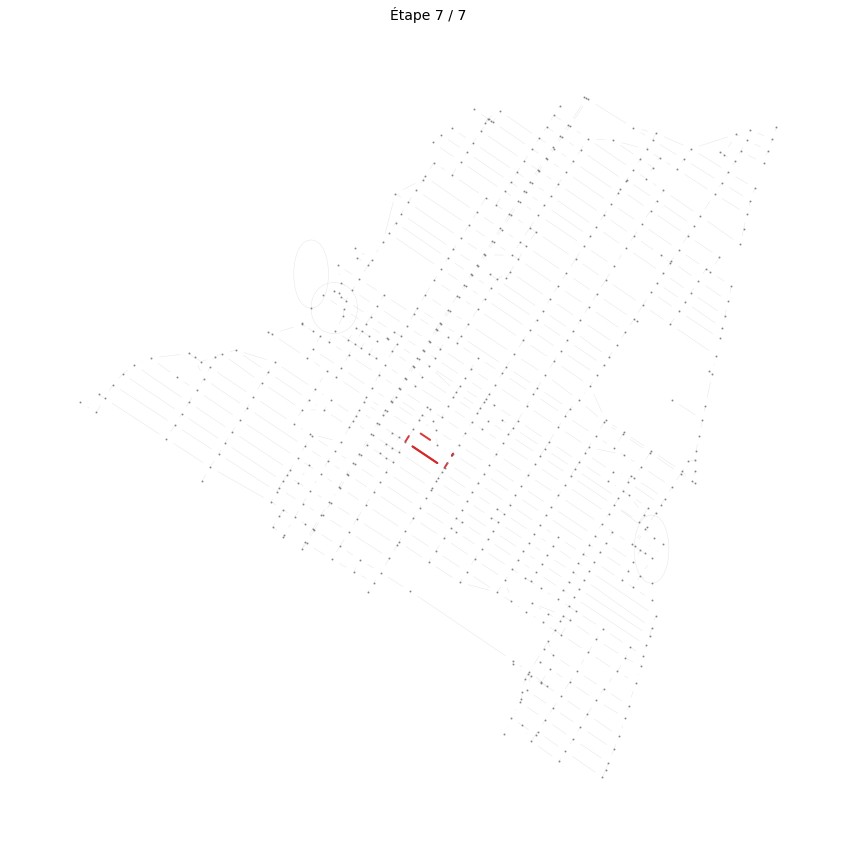

In [32]:
G_aug = nx.MultiGraph(G)

# Position geographique reelle
pos = {node: (data['x'], data['y']) for node, data in G_aug.nodes(data=True)}

circuit = path2

edges_drawn = []

for i, edge in enumerate(circuit):
    edges_drawn.append(edge)

    clear_output(wait=True)
    plt.figure(figsize=(12, 12))

    options = {"edgecolors": "tab:gray", "node_size": 1, "alpha": 0.8}
    nx.draw_networkx_nodes(G_aug, pos, node_color="tab:blue", **options)

    nx.draw_networkx_edges(G_aug, pos, width=0.5, alpha=0.2, edge_color="gray")

    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=snow_edges,
        width=1,
        alpha=0.5,
        edge_color="tab:blue",
    )
    
    nx.draw_networkx_edges(
        G_aug,
        pos,
        edgelist=edges_drawn,
        width=2,
        alpha=0.9,
        edge_color="tab:red",
    )

    plt.title(f"Étape {i+1} / {len(circuit)}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()